In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression

In [2]:
os.listdir()

['data', 'eda.ipynb']

In [3]:
train = pd.read_parquet('data/train.parquet')
test = pd.read_parquet('data/test.parquet')
original = pd.read_parquet('data/original.parquet')

In [4]:
original.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [5]:
original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [6]:
original.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


In [7]:
train.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [8]:
cat_cols = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Thallium', 'Number of vessels fluro']
for i in cat_cols:
    print('---------------')
    print(train[i].value_counts())
    

---------------
Sex
1    450283
0    179717
Name: count, dtype: int64
---------------
Chest pain type
4    329179
3    197278
2     74941
1     28602
Name: count, dtype: int64
---------------
FBS over 120
0    579608
1     50392
Name: count, dtype: int64
---------------
EKG results
0    320116
2    308562
1      1322
Name: count, dtype: int64
---------------
Exercise angina
0    457553
1    172447
Name: count, dtype: int64
---------------
Slope of ST
1    358293
2    256215
3     15492
Name: count, dtype: int64
---------------
Thallium
3    372286
7    246748
6     10966
Name: count, dtype: int64
---------------
Number of vessels fluro
0    445862
1    106978
2     54303
3     22857
Name: count, dtype: int64


In [9]:
train['Heart Disease'].value_counts()

Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64

In [10]:
train.info()
# 0.44833968253968254 44% Absence
# 0.5516603174603174 55% Presence

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [11]:
df = train.copy()

In [17]:
df['target'] = (df['Heart Disease'] == 'Presence').astype(int)

In [19]:
df = df.drop(columns='Heart Disease')

In [27]:
def col_check(df, column: str):
  vessel_col = column

  prob_table = (
      df.groupby(vessel_col)["target"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "P(Presence)"})
  )

  print(prob_table)

  plt.figure()
  plt.plot(prob_table.index, prob_table["P(Presence)"], marker="o")
  plt.xlabel(column)
  plt.ylabel("P(Heart Disease = Presence)")
  plt.title("Conditional Probability of Heart Disease")
  plt.grid(True)
  plt.show()


     P(Presence)   count
Sex                     
0       0.178764  179717
1       0.555933  450283


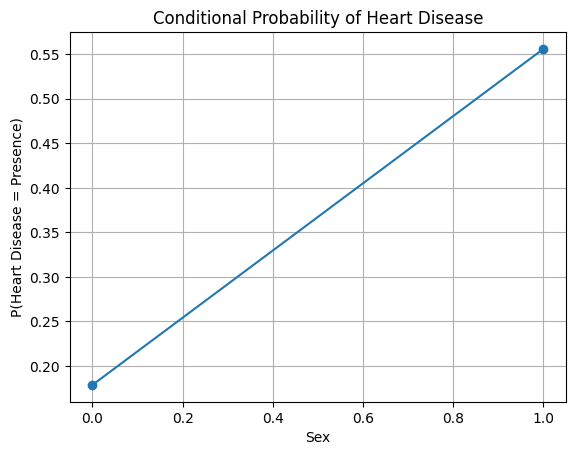

                 P(Presence)   count
Chest pain type                     
1                   0.108069   28602
2                   0.162181   74941
3                   0.190665  197278
4                   0.697478  329179


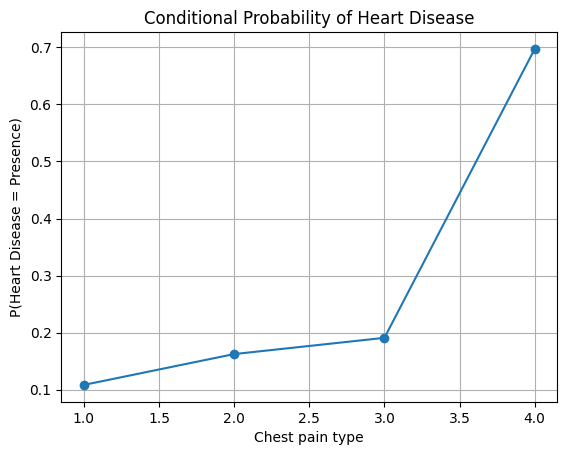

              P(Presence)   count
FBS over 120                     
0                0.443417  579608
1                0.504961   50392


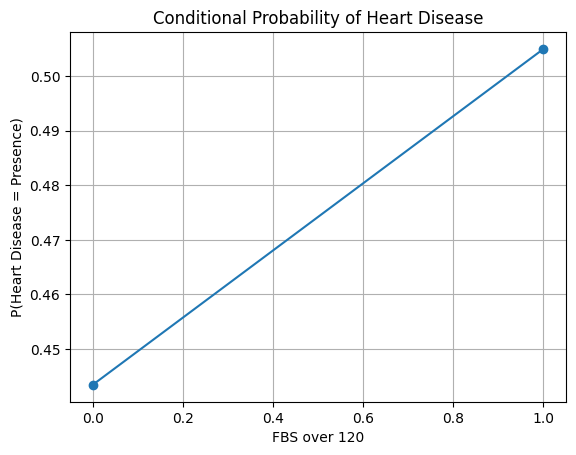

             P(Presence)   count
EKG results                     
0               0.341498  320116
1               0.360061    1322
2               0.559560  308562


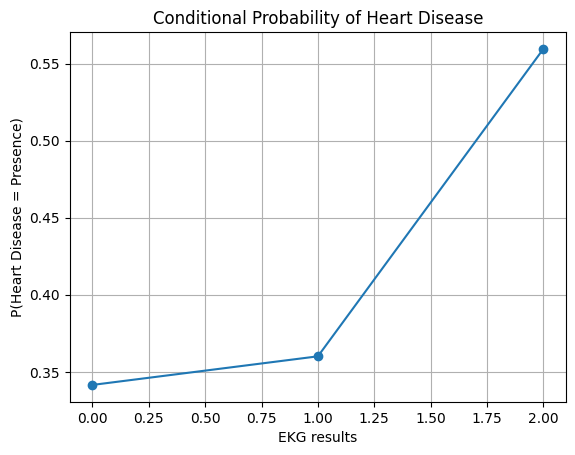

                 P(Presence)   count
Exercise angina                     
0                   0.313433  457553
1                   0.806288  172447


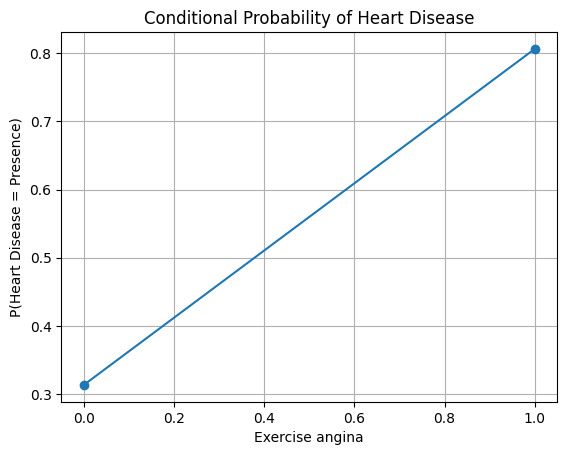

             P(Presence)   count
Slope of ST                     
1               0.262257  358293
2               0.692067  256215
3               0.721082   15492


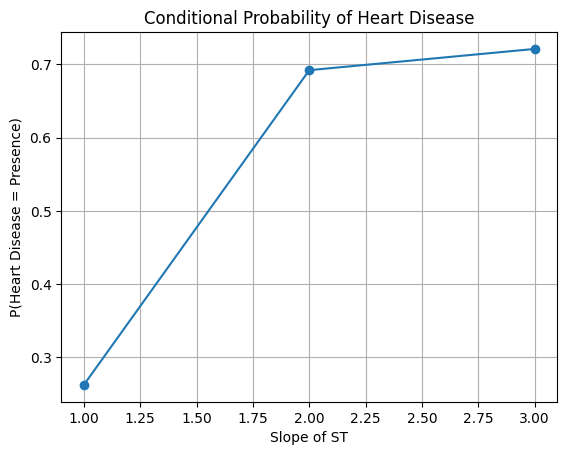

          P(Presence)   count
Thallium                     
3            0.198049  372286
6            0.686394   10966
7            0.815391  246748


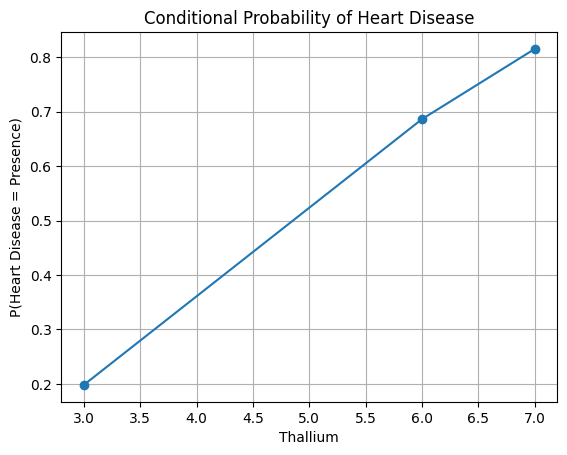

                         P(Presence)   count
Number of vessels fluro                     
0                           0.303132  445862
1                           0.729346  106978
2                           0.897078   54303
3                           0.899549   22857


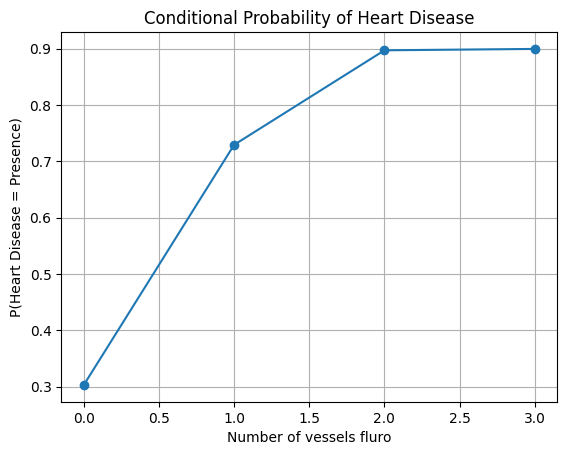

In [28]:
for i in cat_cols:
    col_check(df, i)

In [24]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=["target"])
y = df["target"]

num_cols = X.select_dtypes(include=["int64", "float64"]).columns

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[num_cols] = scaler.fit_transform(X[num_cols])

lr = LogisticRegression(max_iter=1000)
lr.fit(X_scaled, y)

coef = pd.Series(lr.coef_[0], index=X.columns)
coef.loc[vessel_col]

# np.exp(coef.loc[vessel_col])


np.float64(0.705423822311079)